# Driver performance degradation prediction

In [2]:
# Setup and Imports
import sys
sys.path.append('../')  # Add parent directory to path

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Enable FastF1 cache
fastf1.Cache.enable_cache('../data/raw')
sns.set_style('whitegrid')

print("✅ Imports complete")
print(f"FastF1 version: {fastf1.__version__}")

✅ Imports complete
FastF1 version: 3.7.0


In [3]:
# Get 2024 F1 Season Schedule
schedule = fastf1.get_event_schedule(2024)

print(f"Total races in 2024: {len(schedule)}")
print("\n📅 First 10 races:")
schedule[['RoundNumber', 'EventName', 'EventDate', 'Country']].head(10)

Total races in 2024: 25

📅 First 10 races:


,RoundNumber,EventName,EventDate,Country
0,0,Pre-Season Testing,2024-02-23,Bahrain
1,1,Bahrain Grand Prix,2024-03-02,Bahrain
2,2,Saudi Arabian Grand Prix,2024-03-09,Saudi Arabia
3,3,Australian Grand Prix,2024-03-24,Australia
4,4,Japanese Grand Prix,2024-04-07,Japan
5,5,Chinese Grand Prix,2024-04-21,China
6,6,Miami Grand Prix,2024-05-05,United States
7,7,Emilia Romagna Grand Prix,2024-05-19,Italy
8,8,Monaco Grand Prix,2024-05-26,Monaco
9,9,Canadian Grand Prix,2024-06-09,Canada


In [6]:
# Load 2024 Bahrain GP Race
print("Loading 2024 Bahrain GP...")
session = fastf1.get_session(2024, 1, 'R')
session.load()

print(f"✅ Race loaded: {session.event['EventName']}")
print(f"📍 Circuit: {session.event['Location']}")
print(f"📅 Date: {session.event['EventDate']}")
print(f"🏁 Total laps recorded: {len(session.laps)}")

# Get driver statistics 
print("="*50) 
print("DRIVER STATISTICS") 
print("="*50) 

# Total unique drivers 
driver_count = clean_laps['Driver'].nunique() 
print(f"Total unique drivers: {driver_count}") 

# Laps per driver 
laps_per_driver = clean_laps.groupby('Driver').size() 
min_laps = laps_per_driver.min() 
max_laps = laps_per_driver.max() 
mean_laps = laps_per_driver.mean() 
print(f"Minimum laps (any driver): {min_laps}") 
print(f"Maximum laps (any driver): {max_laps}") 
print(f"Average laps per driver: {mean_laps:.1f}") 
print("\n" + "="*50) 
print("TOP 5 DRIVERS BY LAP COUNT") 
print("="*50) 
print(laps_per_driver.sort_values(ascending=False).head()) 
print("\n" + "="*50) 
print("BOTTOM 5 DRIVERS BY LAP COUNT") 
print("="*50) 
print(laps_per_driver.sort_values(ascending=True).head())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info


Loading 2024 Bahrain GP...


req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


✅ Race loaded: Bahrain Grand Prix
📍 Circuit: Sakhir
📅 Date: 2024-03-02 00:00:00
🏁 Total laps recorded: 1129
DRIVER STATISTICS
Total unique drivers: 20
Minimum laps (any driver): 48
Maximum laps (any driver): 52
Average laps per driver: 51.2

TOP 5 DRIVERS BY LAP COUNT
Driver
ALO    52
PER    52
LEC    52
HAM    52
STR    52
dtype: int64

BOTTOM 5 DRIVERS BY LAP COUNT
Driver
SAR    48
GAS    49
HUL    50
BOT    51
MAG    51
dtype: int64


In [ ]:
# Get all laps from the session
laps = session.laps.copy()

# Convert times to seconds
for col in ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']:
    laps[col] = laps[col].dt.total_seconds()

# Remove invalid laps
clean_laps = laps[laps['IsAccurate'] == True].copy()

print(f"Total laps: {len(laps)}")
print(f"Valid laps: {len(clean_laps)}")
print(f"Invalid laps removed: {len(laps) - len(clean_laps)}")

# Show sample
clean_laps[['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife']].head(10)

Total laps: 1129
Valid laps: 1024
Invalid laps removed: 105


,Driver,LapNumber,LapTime,Compound,TyreLife
1,VER,2.0,96.296,SOFT,5.0
2,VER,3.0,96.753,SOFT,6.0
3,VER,4.0,96.647,SOFT,7.0
4,VER,5.0,97.173,SOFT,8.0
5,VER,6.0,97.092,SOFT,9.0
6,VER,7.0,97.038,SOFT,10.0
7,VER,8.0,97.024,SOFT,11.0
8,VER,9.0,97.229,SOFT,12.0
9,VER,10.0,96.960,SOFT,13.0
10,VER,11.0,97.085,SOFT,14.0


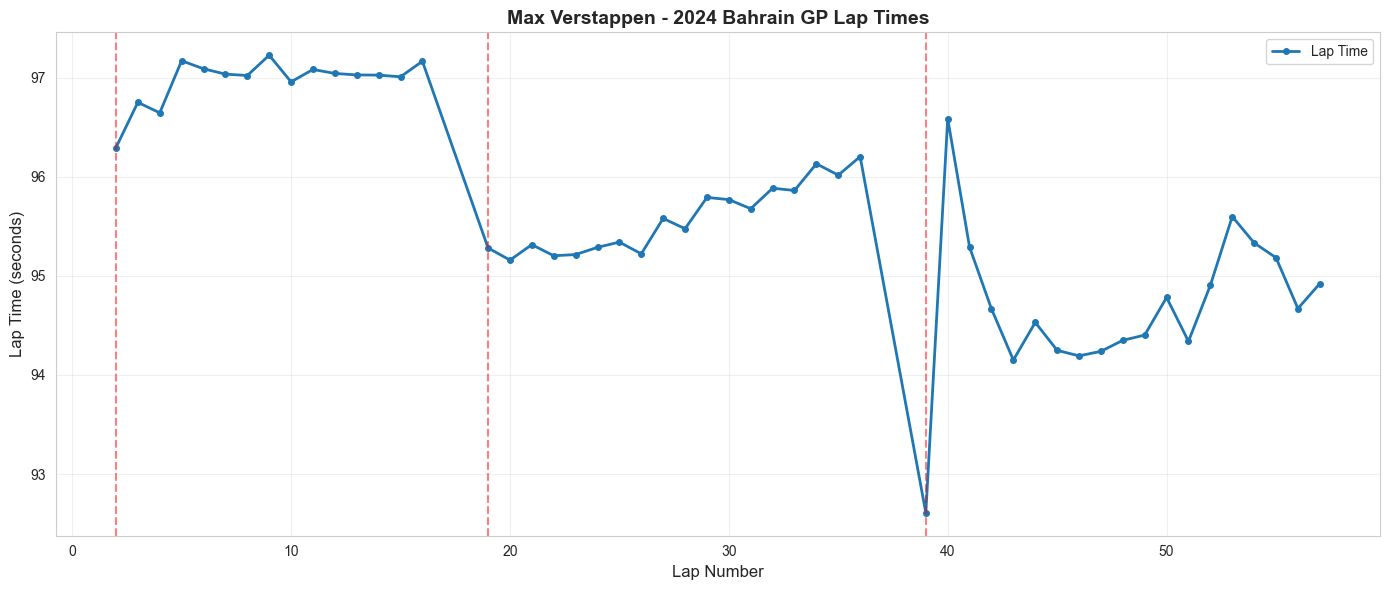

Average lap time: 95.65s
Fastest lap: 92.61s
Slowest lap: 97.23s


In [5]:
# Get Max Verstappen's laps
ver_laps = clean_laps[clean_laps['Driver'] == 'VER'].copy()

plt.figure(figsize=(14, 6))

# Plot lap times
plt.plot(ver_laps['LapNumber'], ver_laps['LapTime'], 
         marker='o', linewidth=2, markersize=4, label='Lap Time')

# Mark pit stops (where stint changes)
pit_stops = ver_laps[ver_laps['LapNumber'].diff() != 1]['LapNumber']
for pit_lap in pit_stops:
    plt.axvline(x=pit_lap, color='red', linestyle='--', alpha=0.5)

plt.xlabel('Lap Number', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('Max Verstappen - 2024 Bahrain GP Lap Times', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average lap time: {ver_laps['LapTime'].mean():.2f}s")
print(f"Fastest lap: {ver_laps['LapTime'].min():.2f}s")
print(f"Slowest lap: {ver_laps['LapTime'].max():.2f}s")

In [6]:
# Load first 3 races of 2024
from src.data_loader import F1DataLoader

loader = F1DataLoader(cache_dir='../data/raw')

# Fetch races 1, 2, 3 (Bahrain, Saudi Arabia, Australia)
multi_race_data = loader.get_multi_race_data(
    year=2024,
    races=[1, 2, 3],
    session_type='R'
)

print(f"✅ Loaded {len(multi_race_data)} laps from 3 races")
print(f"📊 Unique drivers: {multi_race_data['Driver'].nunique()}")
print(f"🏁 Races: {multi_race_data['EventName'].unique()}")

✅ Cache enabled at: D:\Research Projects\F1_Performance_Degradation\notebooks\..\data\raw


Fetching races:   0%|                                                                            | 0/3 [00:00<?, ?it/s]core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading 2024 Round 1 - R...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
Fetching races:  33%|██████████████████████▋                                             | 1/3 [00:06<00:13,  6.62s/it]core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Loading 2024 Round 2 - R...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27', '23', '20', '31', '2', '22', '3', '77', '24', '18', '10']
Fetching races:  67%|█████████████████████████████████████████████▎                      | 2/3 [00:13<00:07,  7.03s/it]core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_

Loading 2024 Round 3 - R...


req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['55', '16', '4', '81', '11', '18', '22', '14', '27', '20', '23', '3', '10', '77', '24', '31', '63', '44', '1']
Fetching races: 100%|████████████████████████████████████████████████████████████████████| 3/3 [00:21<00:00,  7.08s/it]

✅ Loaded 2697 laps from 3 races
📊 Unique drivers: 21
🏁 Races: ['Bahrain Grand Prix' 'Saudi Arabian Grand Prix' 'Australian Grand Prix']


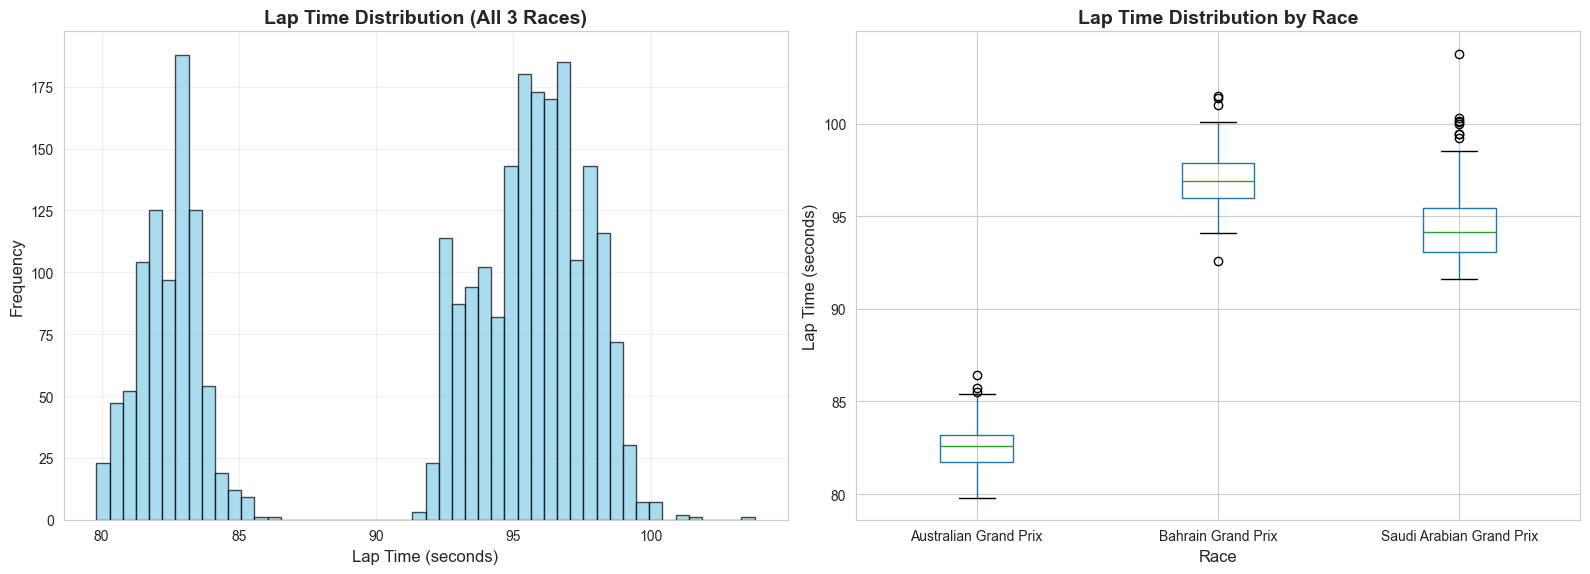

In [7]:
# Visualize lap time distribution across races
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall distribution
axes[0].hist(multi_race_data['LapTime'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Lap Time (seconds)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Lap Time Distribution (All 3 Races)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: By race
multi_race_data.boxplot(column='LapTime', by='EventName', ax=axes[1])
axes[1].set_xlabel('Race', fontsize=12)
axes[1].set_ylabel('Lap Time (seconds)', fontsize=12)
axes[1].set_title('Lap Time Distribution by Race', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

In [8]:
# Save to processed folder
output_path = Path('../data/processed/races_2024_1-3.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)

multi_race_data.to_csv(output_path, index=False)

print(f"💾 Saved to: {output_path}")
print(f"📊 File size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"✅ Data ready for feature engineering!")

💾 Saved to: ..\data\processed\races_2024_1-3.csv
📊 File size: 0.25 MB
✅ Data ready for feature engineering!
